<div style="text-align: center; margin-top: 200px; margin-bottom: 100px;">

# Machine Learning for Data Analytics  
## Assignment 3

<br><br>

**Piotr Czech, Filip Miśkiewicz**

</div>

In [1]:
%%html
<style>
img {
    max-width: 1050px !important;
    margin: 20px auto !important;
    display: block !important;
    border: 2px solid #ccc !important;
    padding: 60px 30px !important;
}
</style>

In [11]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx=" # handles pymc warning

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import torch
import seaborn as sns
import optuna
import pymc as pm
import arviz as az
import yfinance as yf
import itertools

from arch import arch_model
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, WhiteKernel
from sklearn.datasets import fetch_openml
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [3]:
random_state = 333

## Table of Contents

* [Problem 2.1: Bayesian Linear Regression](#problem-31-bayesian-linear-regression)
* [Problem 2.2: Gaussian Process Regression](#problem-32-guassian-process-regression)
* [Problem 2.3: ARIMA Modeling](#problem-33-arima-modeling)
* [Problem 2.4: GARCH for Volatility](#problem-34-garch-for-volatility)

## Problem 3.1: Bayesian Linear Regression

### Objective
Implement Bayesian linear regression using PyMC

### Tasks
- Use a polynomial regression problem with noisy data (use synthetic data
or Advertising Dataset from Kaggle).
- Set appropriate priors for coefficients and noise.
- Sample from the posterior using MCMC.
- Visualize posterior distributions and credible intervals.
- Compare with standard maximum likelihood estimation

We will start with generating the data which follows the formula

$Y_i \sim N(\mu_i,\sigma)$, $\mu_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2$

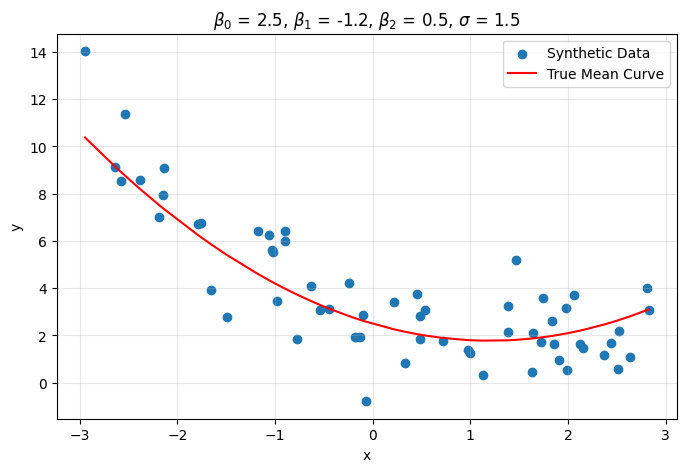

In [4]:
rng = np.random.default_rng(random_state)

n_samples = 60
true_beta_0 = 2.5
true_beta_1 = -1.2
true_beta_2 = 0.5
true_sigma = 1.5

x = np.sort(rng.uniform(-3, 3, n_samples))
true_mu = true_beta_0 + true_beta_1 * x + true_beta_2 * (x**2)
y = rng.normal(true_mu, true_sigma)

plt.figure(figsize=(8, 5))
plt.title(fr"$\beta_0$ = {true_beta_0}, $\beta_1$ = {true_beta_1}, $\beta_2$ = {true_beta_2}, $\sigma$ = {true_sigma}")
plt.scatter(x, y, label="Synthetic Data")
plt.plot(x, true_mu, color="red", label="True Mean Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Now, before building the Bayesian model, we calculate the standard MLE parameters to serve as a baseline for comparison.

MLE Beta 0: 2.64
MLE Beta 1: -1.42
MLE Beta 2: 0.53


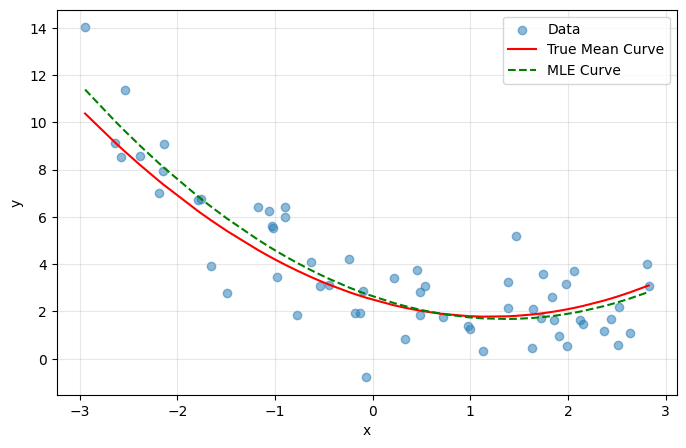

In [5]:
mle_coeffs = np.polyfit(x, y, 2)
mle_beta_2, mle_beta_1, mle_beta_0 = mle_coeffs

mle_mu = mle_beta_0 + mle_beta_1 * x + mle_beta_2 * (x**2)

print(f"MLE Beta 0: {mle_beta_0:.2f}")
print(f"MLE Beta 1: {mle_beta_1:.2f}")
print(f"MLE Beta 2: {mle_beta_2:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label="Data")
plt.plot(x, true_mu, color="red", label="True Mean Curve")
plt.plot(x, mle_mu, color="green", linestyle="--", label="MLE Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

We can see that the MLE curve is very close to the true mean curve. However, it is slightly above the original line for the lower values of x, and below it for the higher arguments.

At this stage, we can define the Bayesian model using PyMC. We assign weakly informative Normal priors for the coefficients $\beta$ and a Half-Normal prior for the standard deviation $\sigma$. The default MCMC sampler handles multiple chains automatically.

In [6]:
with pm.Model() as poly_model:
    beta_0 = pm.Normal("beta_0", mu=0, sigma=10)
    beta_1 = pm.Normal("beta_1", mu=0, sigma=10)
    beta_2 = pm.Normal("beta_2", mu=0, sigma=10)
    
    sigma = pm.HalfNormal("sigma", sigma=5)
    
    mu = beta_0 + beta_1 * x + beta_2 * (x**2)
    
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=y)
    
    trace = pm.sample(2000, tune=1000, chains=4, return_inferencedata=True, random_seed=random_state)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_1, beta_2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 130 seconds.


Now we use ArviZ to inspect the MCMC chains and visualize the posterior probability distributions for all parameters, highlighting the 94% credible intervals.

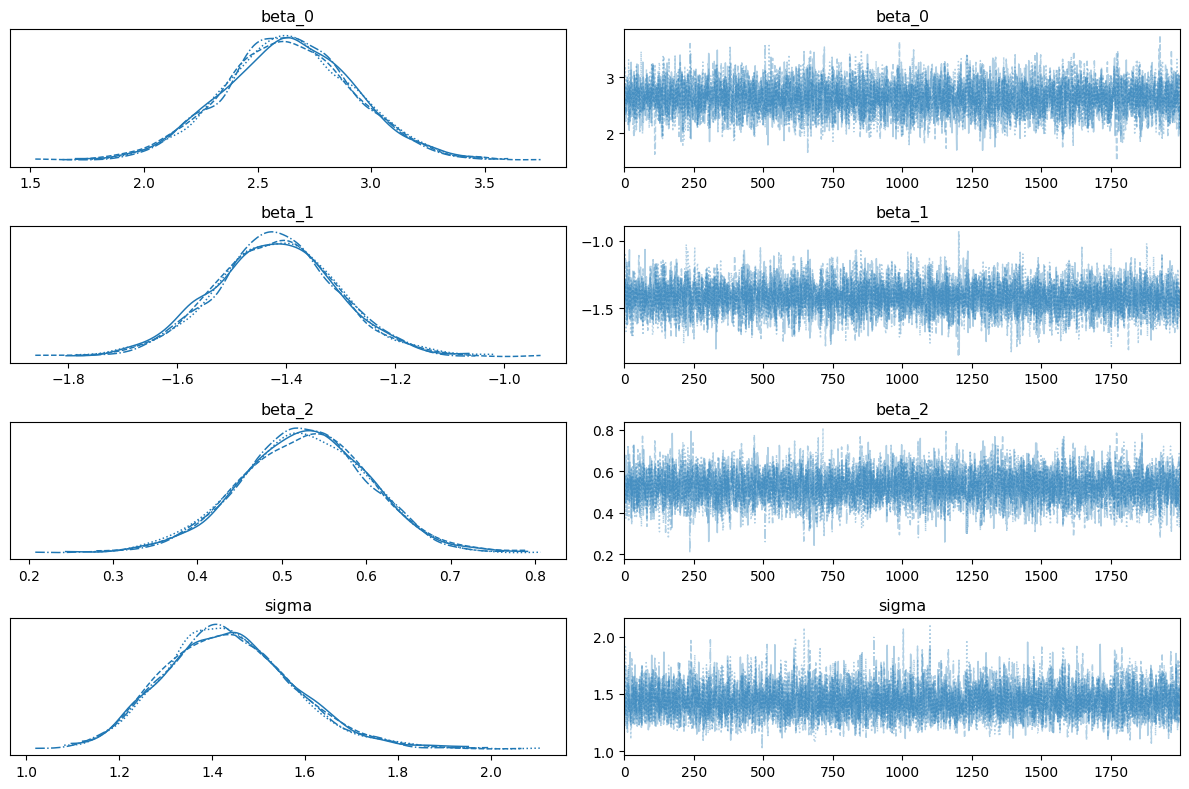

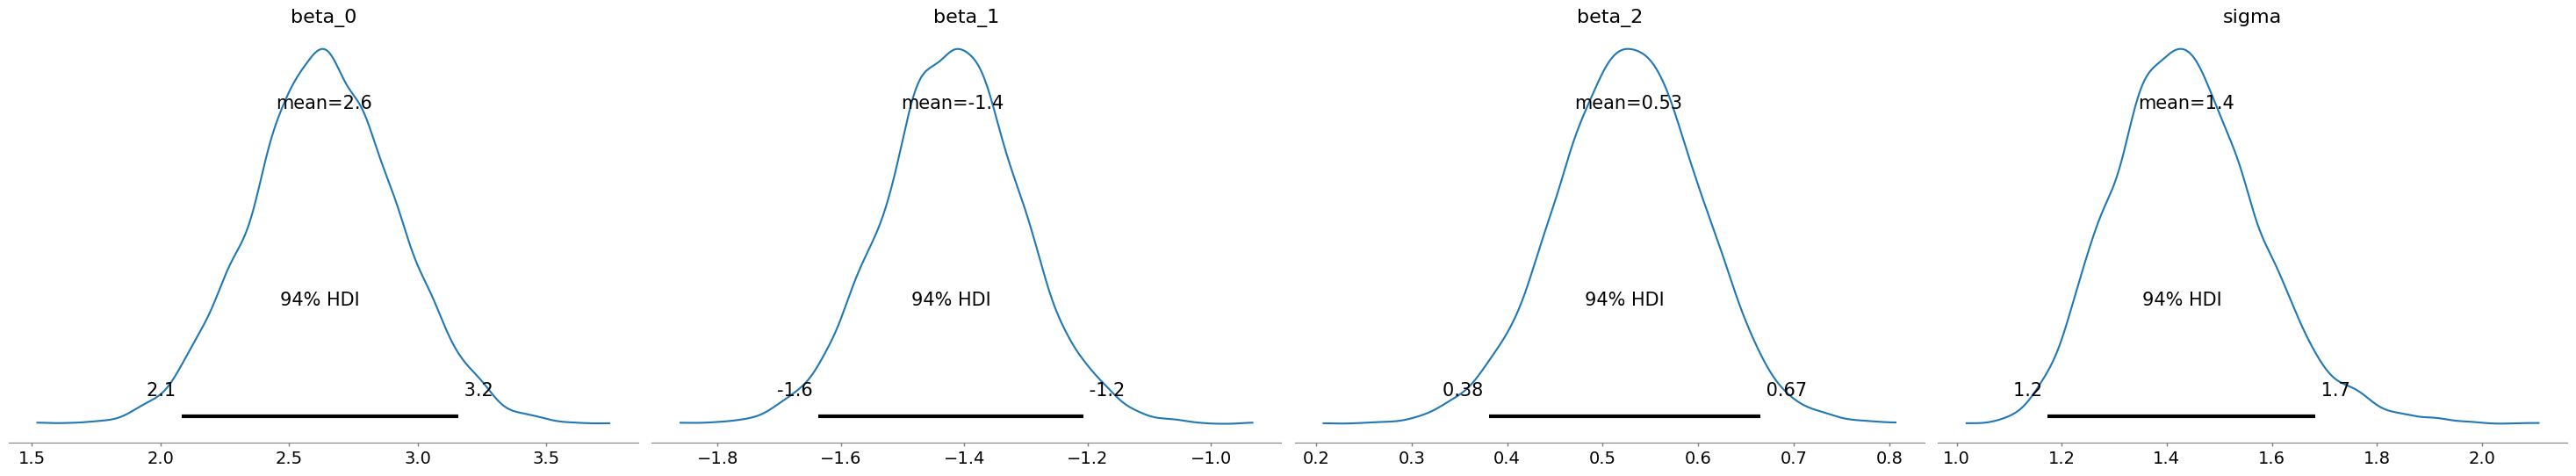

In [7]:
az.plot_trace(trace, var_names=["beta_0", "beta_1", "beta_2", "sigma"])
plt.tight_layout()
plt.show()

az.plot_posterior(trace, var_names=["beta_0", "beta_1", "beta_2", "sigma"], hdi_prob=0.94)
plt.tight_layout()
plt.show()

The left column of the trace plot contains Kernel Density Estimation plots. They represent the posterior probability distribution for each parameter. The multiple lines represent the different, independent Markov chains and all of them overlap almost perfectly for each parameter, which indicates the convergence. The plots on the right side show the sequential history of the values sampled by the MCMC algorithm across all iterations. The chains bounce rapidly and randomly around a central mean.

The posterior plot shows us the estimated parameters with the credential intervals. We can compare the results by taking the mean.

In [8]:
post_beta_0 = float(trace.posterior["beta_0"].mean())
post_beta_1 = float(trace.posterior["beta_1"].mean())
post_beta_2 = float(trace.posterior["beta_2"].mean())
post_sigma = float(trace.posterior["sigma"].mean())

mle_residuals = y - mle_mu
mle_sigma = np.std(mle_residuals)

comparison_data = {
    "Parameter": ["beta_0", "beta_1", "beta_2", "sigma"],
    "True Value": [true_beta_0, true_beta_1, true_beta_2, true_sigma],
    "MLE Value": [mle_beta_0, mle_beta_1, mle_beta_2, mle_sigma],
    "Posterior Mean": [post_beta_0, post_beta_1, post_beta_2, post_sigma]
}

comparison_df = pd.DataFrame(comparison_data)

print("Parameter comparison:")
print(comparison_df.to_string(index=False))

Parameter comparison:
Parameter  True Value  MLE Value  Posterior Mean
   beta_0         2.5   2.641739        2.634937
   beta_1        -1.2  -1.420077       -1.420092
   beta_2         0.5   0.525857        0.526697
    sigma         1.5   1.374330        1.437666


All of the obtained posterior results are very close to the MLE values. The posterior mean was a slightly more accurate estimation of the $\sigma$ parameter.

Now we can extract the sampled parameters to reconstruct the estimated polynomial function. This allows us to calculate the posterior mean curve and the 94% highest density interval (HDI) for the expected value $\mu_i$​, comparing it directly against the MLE and the true underlying curve.

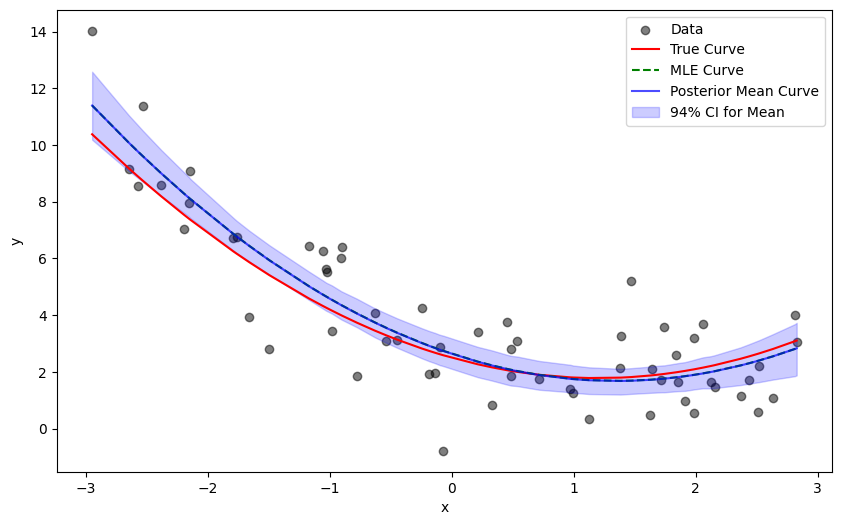

In [9]:
posterior = trace.posterior
beta_0_samples = posterior["beta_0"].values.flatten()
beta_1_samples = posterior["beta_1"].values.flatten()
beta_2_samples = posterior["beta_2"].values.flatten()

mu_samples = beta_0_samples[:, None] + beta_1_samples[:, None] * x + beta_2_samples[:, None] * (x**2)

mu_mean = mu_samples.mean(axis=0)
mu_hdi = az.hdi(mu_samples, hdi_prob=0.94)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, color="black", label="Data")
plt.plot(x, true_mu, color="red", label="True Curve")
plt.plot(x, mle_mu, color="green", linestyle="--", label="MLE Curve")
plt.plot(x, mu_mean, color="blue", label="Posterior Mean Curve", alpha = 0.7)

plt.fill_between(x, mu_hdi[:, 0], mu_hdi[:, 1], color="blue", alpha=0.2, label="94% CI for Mean")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

The posterior mean curve and MLE curve almost perfectly overlap, being a close approximation of the original function.

Finally, we generate samples from the posterior predictive distribution. This accounts for both the uncertainty in the parameters and the inherent noise $\sigma$, providing the 94% credible interval for the actual observations $y_i$​.

Sampling: [Y_obs]


Output()

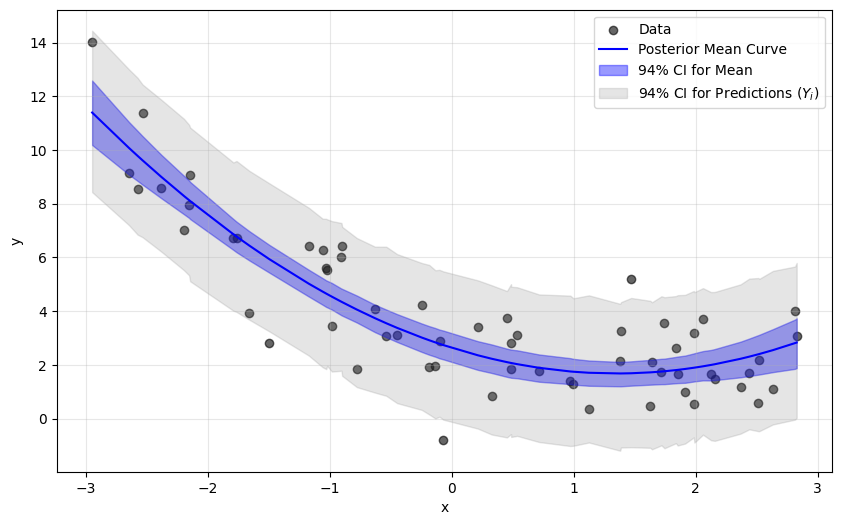

In [10]:
with poly_model:
    posterior_predictive = pm.sample_posterior_predictive(trace, random_seed=random_state)

y_pred_samples = posterior_predictive.posterior_predictive["Y_obs"]
y_hdi = az.hdi(y_pred_samples, hdi_prob=0.94).Y_obs.values

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, color="black", label="Data")
plt.plot(x, mu_mean, color="blue", label="Posterior Mean Curve")

plt.fill_between(x, mu_hdi[:, 0], mu_hdi[:, 1], color="blue", alpha=0.4, label="94% CI for Mean")
plt.fill_between(x, y_hdi[:, 0], y_hdi[:, 1], color="gray", alpha=0.2, label=fr"94% CI for Predictions ($Y_i$)")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

In fact, there are only a few points that do not belong to the credible interval.

## Problem 3.2: Gaussian Process Regression

### Objective
Apply Gaussian Processes to function approximation

### Tasks
- Use GPyTorch or scikit-learn.
- Test on synthetic 1D and 2D functions.
- Use Mauna Loa CO2 dataset or temperature time series from your hometown
- Experiment with different kernels (RBF, Matern, Periodic).
- Visualize mean predictions and uncertainty bounds.
- Discuss computational complexity for large datasets.

We use the `scikit-learn` implementation of GPR.

### 1. Function approximation in 1D


We begin with a simple one-dimensional regression problem. The purpose of this experiment is to verify whether Gaussian Processes can reconstruct a smooth nonlinear function from a small number of noisy observations.

The chosen target function combines sine and cosine components, which makes it nonlinear but still easy to visualize.

In [5]:
def f_1d(x):
    return np.sin(x) + 0.3 * np.cos(2 * x)

X_train_1d = np.linspace(0, 10, 20).reshape(-1, 1)  
# reshape(-1, 1) converts the vector into a column format required by scikit-learn
y_train_1d = f_1d(X_train_1d).ravel() + np.random.normal(0, 0.2, X_train_1d.shape[0])  
# .ravel() flattens the array from shape (n, 1) to shape (n,)

X_test_1d = np.linspace(0, 10, 300).reshape(-1, 1)

Before fitting the model, it is useful to inspect the noisy training samples and compare them with the true underlying function.

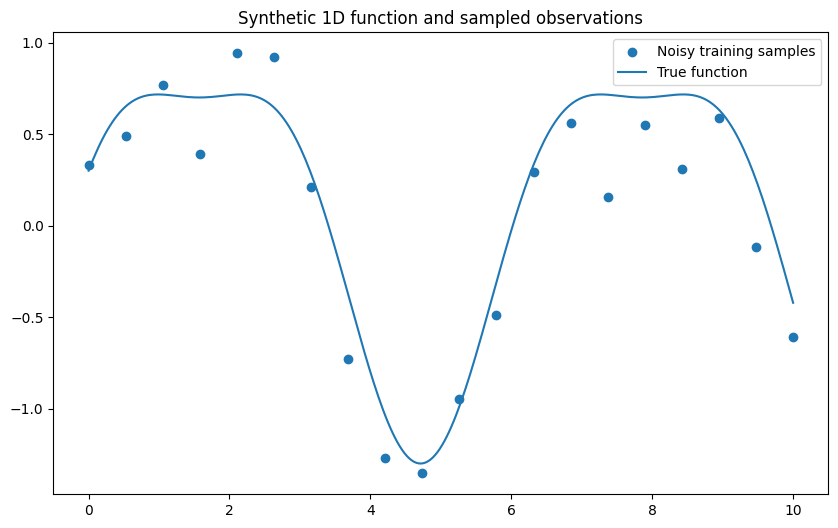

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_1d, y_train_1d, label="Noisy training samples")
plt.plot(X_test_1d, f_1d(X_test_1d), label="True function")
plt.title("Synthetic 1D function and sampled observations")
plt.legend()
plt.show()

The first experiment uses the RBF kernel, which assumes a smooth underlying function. A WhiteKernel component is added to explicitly model noise in the observations.

Gaussian Process returns:
- the mean prediction,
- the predictive standard deviation, which represents uncertainty.

In [7]:
kernel_rbf = RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

gpr_rbf_1d = GaussianProcessRegressor(kernel=kernel_rbf)
gpr_rbf_1d.fit(X_train_1d, y_train_1d)

y_pred_1d, y_std_1d = gpr_rbf_1d.predict(X_test_1d, return_std=True)
# return_std=True returns the standard deviation for each prediction

and lets visualize it

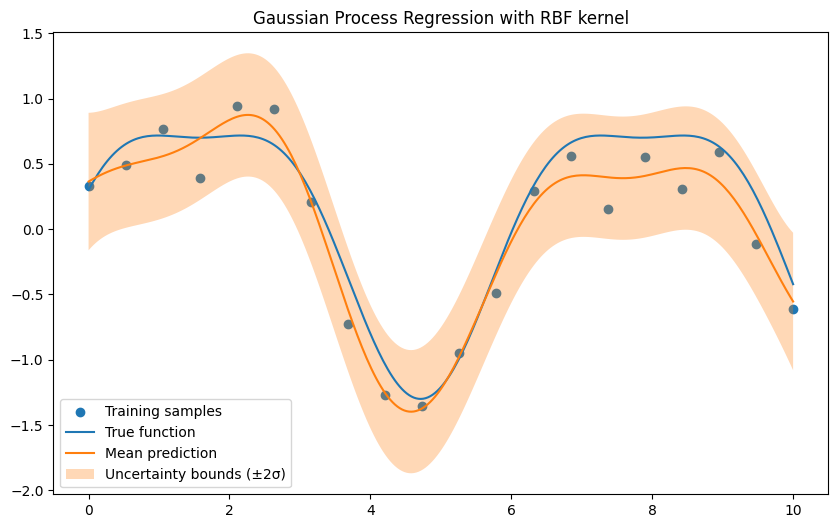

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_1d, y_train_1d, label="Training samples")
plt.plot(X_test_1d, f_1d(X_test_1d), label="True function")
plt.plot(X_test_1d, y_pred_1d, label="Mean prediction")

plt.fill_between(
    X_test_1d.ravel(),  
    # .ravel() converts X values to 1D, which is required by fill_between
    y_pred_1d - 2 * y_std_1d,
    y_pred_1d + 2 * y_std_1d,
    alpha=0.3,
    label="Uncertainty bounds (±2σ)"
)

plt.title("Gaussian Process Regression with RBF kernel")
plt.legend()
plt.show()

The Gaussian Process with the RBF kernel reconstructs the overall shape of the target function reasonably well. The predicted mean follows the nonlinear trend of the data, although some differences can be seen in the central point, where the model produces a smoother approximation than the true function.

The uncertainty band is relatively wide, which is expected because the model was trained on a small number of noisy observations. At the same time, the uncertainty remains lower near training samples and increases in regions where the local behavior of the function is harder to infer.

Overall, the result confirms that Gaussian Processes are well suited for smooth nonlinear regression tasks and provide useful uncertainty estimates together with predictions.

### 2. Comparison of Different Kernels in 1D

The choice of kernel has a major impact on the behavior of a Gaussian Process. We compare three kernels
- **RBF**, produces very smooth functions
- **Matern**: allows less smooth, more flexible behavior
- **Periodic**: is designed for repeating patterns.

In [9]:
kernels_1d = {
    "RBF": RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1),
    "Matern": Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=0.1),
    "Periodic": ExpSineSquared(length_scale=1.0, periodicity=3.0) + WhiteKernel(noise_level=0.1)
}

Each kernel is fitted separately.  

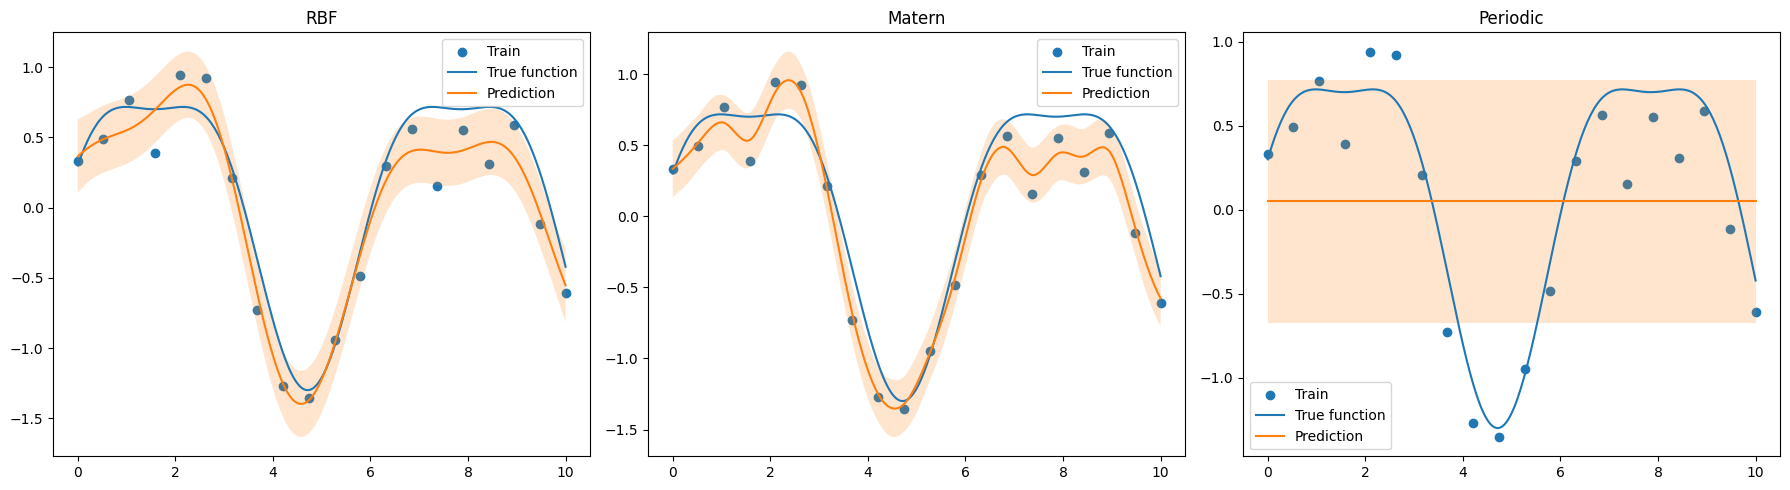

In [10]:
plt.figure(figsize=(18, 5))

for i, (kernel_name, kernel) in enumerate(kernels_1d.items(), start=1):
    gpr_model = GaussianProcessRegressor(kernel=kernel)
    gpr_model.fit(X_train_1d, y_train_1d)

    y_pred_kernel, y_std_kernel = gpr_model.predict(X_test_1d, return_std=True)

    plt.subplot(1, 3, i)
    plt.scatter(X_train_1d, y_train_1d, label="Train")
    plt.plot(X_test_1d, f_1d(X_test_1d), label="True function")
    plt.plot(X_test_1d, y_pred_kernel, label="Prediction")

    plt.fill_between(
        X_test_1d.ravel(),
        y_pred_kernel - y_std_kernel,
        y_pred_kernel + y_std_kernel,
        alpha=0.2
    )

    plt.title(kernel_name)
    plt.legend()

plt.tight_layout()
plt.show()

**The RBF and Matern kernels both produce reasonable approximations** of the target function. In both cases, the predicted curve follows the general nonlinear structure of the data and remains consistent with the training samples.

RBF kernel gives the smoothest approximation, which is visible especially around the central minimum and the right-hand peak. The Matern kernel produces a very similar result, but it is slightly more flexible and can better adapt to local changes in the function.

In contrast, **the Periodic kernel performs very poorly**. Instead of capturing the true trend, it generates strong oscillations that do not correspond to the underlying function. This happens because the synthetic target is not truly periodic, so the assumptions of the Periodic kernel are not appropriate for this problem.

Therefore, for this dataset, the RBF and Matern kernels are clearly more suitable than the Periodic kernel.

### 3. Gaussian Process Regression on a Synthetic 2D Function

After the one-dimensional example, the model is extended to two input dimensions. The selected function combines sine and cosine terms in two coordinates, producing a structured response surface. Random 2D points are sampled from a square domain.  

In [11]:
def f_2d(X):
    return np.sin(X[:, 0]) + np.cos(X[:, 1])
    # X[:, 0] selects the first feature
    # X[:, 1] selects the second feature

X_train_2d = np.random.uniform(0, 5, (100, 2))
y_train_2d = f_2d(X_train_2d) + np.random.normal(0, 0.1, 100)

for simplicity, an RBF kernel is used again

In [12]:
kernel_2d = RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

gpr_2d = GaussianProcessRegressor(kernel=kernel_2d)
gpr_2d.fit(X_train_2d, y_train_2d)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",RBF(length_sc...ise_level=0.1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",0
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`G

to visualize the model, a regular grid is constructed over the input space

In [13]:
grid_x, grid_y = np.meshgrid(
    np.linspace(0, 5, 60),
    np.linspace(0, 5, 60)
)

X_test_2d = np.column_stack([grid_x.ravel(), grid_y.ravel()])
# .ravel() flattens each grid into a 1D vector
# np.column_stack combines both vectors into shape (n_points, 2)

y_pred_2d, y_std_2d = gpr_2d.predict(X_test_2d, return_std=True)

The contour plot below presents the predicted mean values over the 2D input space.

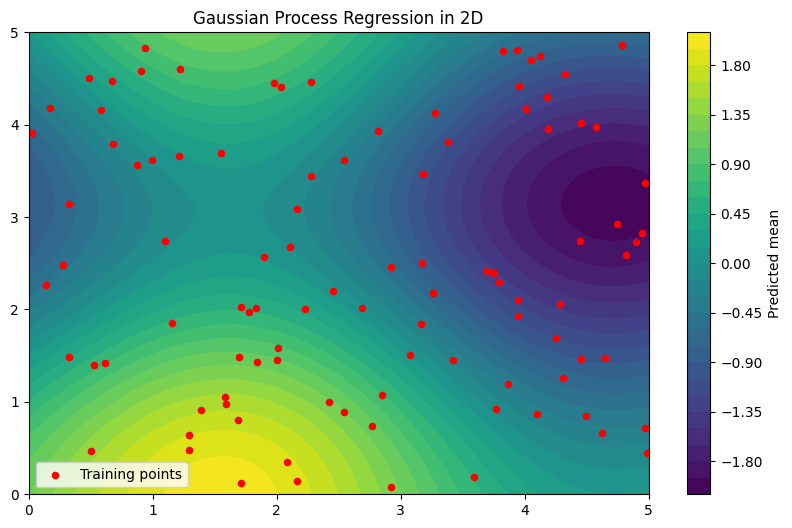

In [14]:
plt.figure(figsize=(10, 6))
plt.contourf(grid_x, grid_y, y_pred_2d.reshape(grid_x.shape), levels=30)
# reshape(grid_x.shape) restores the flat predictions back to the 2D grid shape

plt.colorbar(label="Predicted mean")
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c="red", s=20, label="Training points")
plt.title("Gaussian Process Regression in 2D")
plt.legend()
plt.show()

The next plot presents the predictive standard deviation over the 2D input space. Lower values indicate regions where the model is more confident, while higher values indicate regions where predictions are less certain.

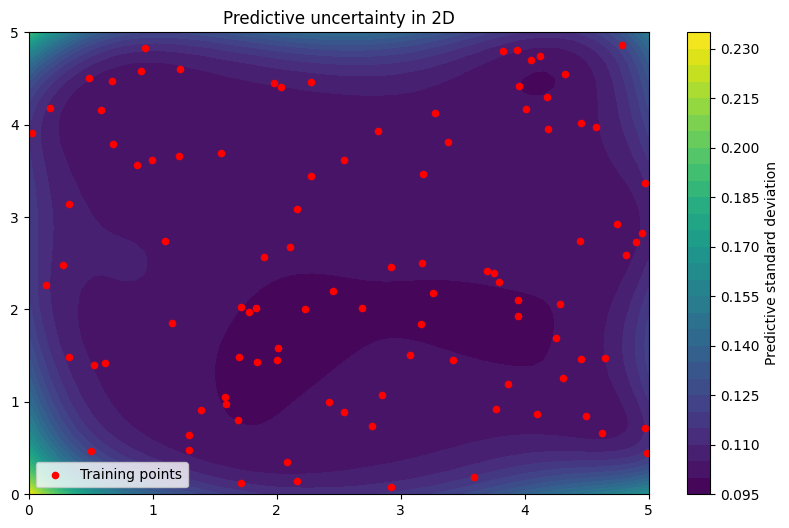

In [15]:
plt.figure(figsize=(10, 6))
plt.contourf(grid_x, grid_y, y_std_2d.reshape(grid_x.shape), levels=30)
plt.colorbar(label="Predictive standard deviation")
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c="red", s=20, label="Training points")
plt.title("Predictive uncertainty in 2D")
plt.legend()
plt.show()

The 2D **Gaussian Process successfully captures the global structure** of the target surface. The predicted mean shows smooth transitions across the input space and reflects the nonlinear combination of sine and cosine components.

The uncertainty plot is also consistent with expectations. The predictive standard deviation is generally lower in regions where training samples are dense and increases near the boundaries of the domain, where fewer observations support the prediction.

This behavior confirms one of the main advantages of Gaussian Processes: in addition to fitting complex nonlinear relationships, they also provide spatial information about how confident the model is in different regions of the input space.

### 4. Mauna Loa CO2

In this section, Gaussian Process Regression is applied to a real-world time series dataset. The dataset contains atmospheric CO2 measurements collected at the Mauna Loa Observatory.

In [16]:
df_co2 = pd.read_csv('./../datasets/co2_mm_mlo.csv')
df_co2.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


The dataset contains missing values marked with negative placeholders such as -9.99 and -1. Before applying Gaussian Processes, these values must be removed.

In [17]:
df_co2_clean = df_co2.copy()
df_co2_clean = df_co2_clean[df_co2_clean['average'] > 0]
df_co2_clean = df_co2_clean.reset_index(drop=True)
df_co2_clean.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


Gaussian Processes require numerical input features. Instead of using separate year and month columns, the "decimal date" feature is used, which represents time as a continuous variable.

**BUT!!!!** Gaussian Processes are sensitive to the scale of input features because the kernel operates on distances between points. The "decimal date" feature contains large values (around 2000), which can lead to numerical instability when computing the covariance matrix. To improve numerical stability, the time variable is shifted so that it starts at zero:

In [18]:
X_co2 = df_co2_clean['decimal date'].values.reshape(-1, 1)
# rescale time to start at zero for numerical stability
X_co2 = X_co2 - X_co2.min()


# reshape to (n_samples, 1) for scikit-learn
y_co2 = df_co2_clean['average'].values

lets see the data

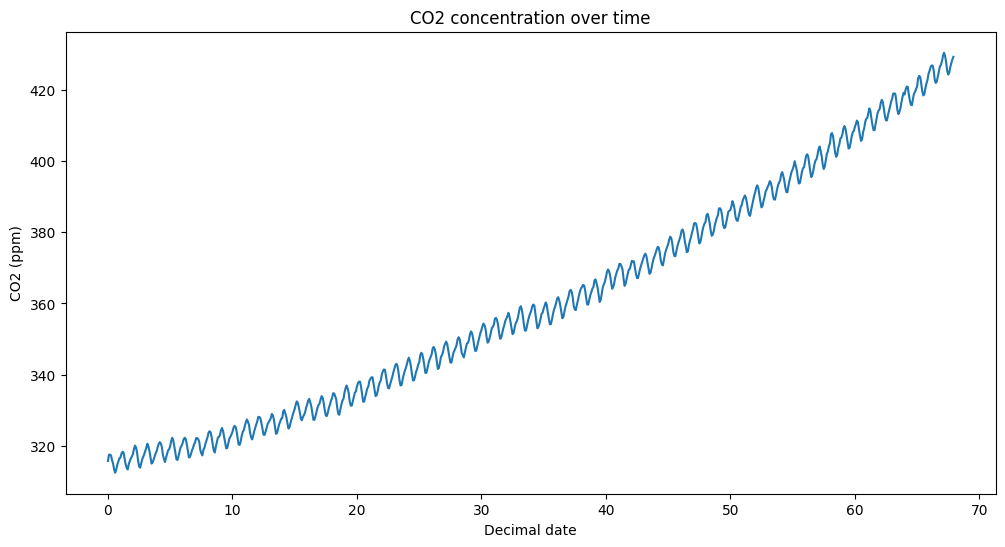

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(X_co2, y_co2)
plt.title("CO2 concentration over time")
plt.xlabel("Decimal date")
plt.ylabel("CO2 (ppm)")
plt.show()

The CO2 time series exhibits two dominant patterns:
- a smooth long-term upward trend,
- regular seasonal oscillations with a period of approximately one year.

To capture both components, a composite kernel is constructed as a sum of three terms:
- an **RBF kernel**, which models the smooth long-term trend,
- an **ExpSineSquared kernel**, which captures the periodic seasonal variation,
- a **WhiteKernel**, which accounts for observational noise.

The RBF kernel is assigned a relatively large length scale, reflecting the slow evolution of CO2 concentration over decades.  
The periodic kernel uses a fixed periodicity close to one year, which corresponds to the annual cycle visible in the data.

To ensure stable training, reasonable bounds are imposed on kernel parameters. This prevents the optimizer from converging to degenerate solutions, such as extremely large noise levels or unrealistic periodicities. Additionally, the model is trained with `normalize_y=True`, which improves numerical stability by centering the target variable internally. (basic model was creating very very poor predictions so all this steps needed to be added.)

In [20]:
kernel_co2 = (
    RBF(length_scale=10.0, length_scale_bounds=(1.0, 30.0)) +
    ExpSineSquared(
        length_scale=1.0,
        periodicity=1.0,
        length_scale_bounds=(0.1, 5.0),
        periodicity_bounds=(0.8, 1.2)
    ) +
    WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 2.0))
)

In this experiment, the Gaussian Process model is first trained on the full cleaned dataset.

This allows us to test whether the model can capture the entire long-term trend and seasonal variation without discarding observations. At the same time, this setup makes it possible to assess the computational cost of Gaussian Processes in practice.

In [21]:
gpr_co2_full = GaussianProcessRegressor(kernel=kernel_co2)

X_train_co2_full = X_co2
y_train_co2_full = y_co2

gpr_co2_full.fit(X_train_co2_full, y_train_co2_full)

y_pred_co2_full, y_std_co2_full = gpr_co2_full.predict(X_train_co2_full, return_std=True)

The following plot compares the observed CO2 values with the Gaussian Process mean prediction and uncertainty bounds. Since the model is trained on the full dataset, the goal here is not only to check predictive quality, but also to evaluate how well the Gaussian Process reconstructs the full structure of the time series.

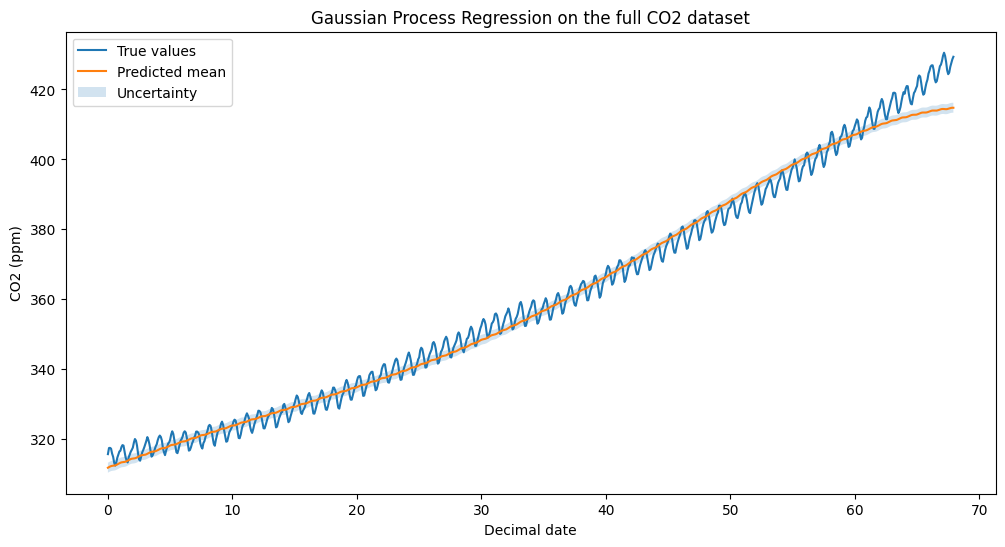

In [22]:
plt.figure(figsize=(12, 6))

plt.plot(X_train_co2_full, y_train_co2_full, label="True values")
plt.plot(X_train_co2_full, y_pred_co2_full, label="Predicted mean")

plt.fill_between(
    X_train_co2_full.ravel(),  
    # .ravel() converts the column vector into 1D for plotting
    y_pred_co2_full - y_std_co2_full,
    y_pred_co2_full + y_std_co2_full,
    alpha=0.2,
    label="Uncertainty"
)

plt.title("Gaussian Process Regression on the full CO2 dataset")
plt.xlabel("Decimal date")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.show()

Although training on the full dataset gives the model access to all observations, it is also useful to compare this approach with a reduced training subset. A smaller subset should train faster, but it may also produce less accurate estimates of trend and seasonal structure.

In [23]:
X_train_co2_small = X_co2[:300]
y_train_co2_small = y_co2[:300]

gpr_co2_small = GaussianProcessRegressor(kernel=kernel_co2)
gpr_co2_small.fit(X_train_co2_small, y_train_co2_small)

y_pred_co2_small, y_std_co2_small = gpr_co2_small.predict(X_train_co2_full, return_std=True)
# predictions are generated on the full input range for direct comparison

The plot below compares two Gaussian Process models:
- one trained on the full dataset,
- one trained on a reduced subset.

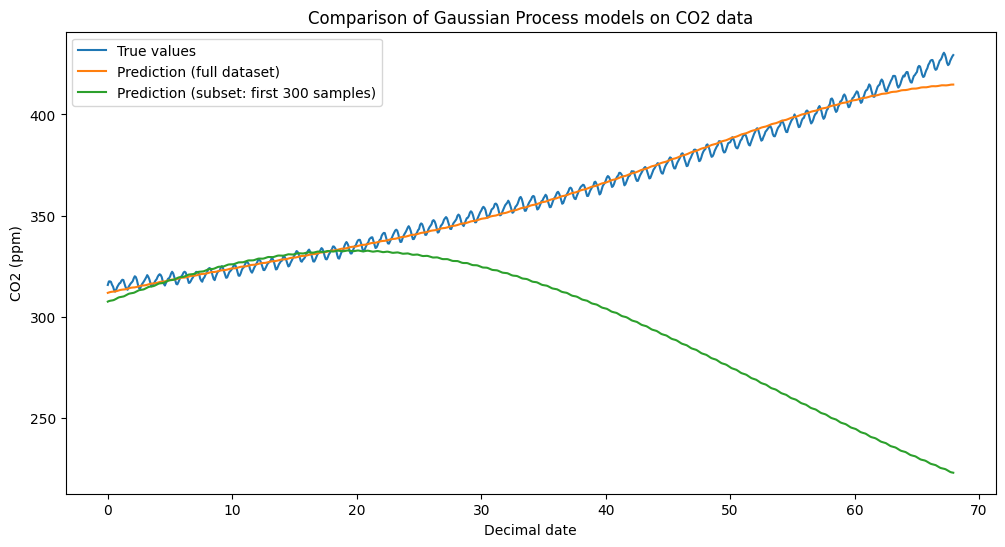

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(X_co2, y_co2, label="True values")
plt.plot(X_train_co2_full, y_pred_co2_full, label="Prediction (full dataset)")
plt.plot(X_train_co2_full, y_pred_co2_small, label="Prediction (subset: first 300 samples)")

plt.title("Comparison of Gaussian Process models on CO2 data")
plt.xlabel("Decimal date")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.show()

The Gaussian Process model trained on the full dataset is able to capture the overall increasing trend of CO2 concentration over time. The predicted mean closely follows the long-term behavior of the data, although the seasonal oscillations are only partially reproduced.

However, this result should be interpreted carefully, because the model is evaluated on the same data that were used for training. This means that the full-dataset experiment mainly shows how well the Gaussian Process can fit the observed series, rather than how well it generalizes to unseen future observations.

In contrast, the model trained on a reduced subset of the data performs significantly worse when evaluated over the full time range. While it fits the initial portion of the series reasonably well, it fails to extrapolate the trend and produces unrealistic predictions in later periods.

Additionaly, it can be observed that the Gaussian Process model captures the global trend more reliably than the high-frequency seasonal fluctuations. This suggests that the RBF component dominates the model, while the periodic component may require further tuning to better match the amplitude and shape of seasonal variations.

This comparison suggests that Gaussian Processes can model the observed structure effectively, but their long-range extrapolation ability is limited when future data are not available during training. In other words, the apparent performance of the full-data model is much stronger than the realistic forecasting performance of the subset-based model.

## Problem 3.3:  ARIMA Modelling

### Objective
Forecast stock prices using ARIMA.

### Tasks
- Download daily prices for any stock (2+ years of data).
- Check for stationarity using ADF test.
- Use ACF/PACF plots to determine ARIMA order.
- Fit ARIMA model and validate using last 20% of data.
- Generate 30-day forecast with confidence intervals.

Firstly, we will download Apple (AAPL) stock data covering a period of three years. We extract the closing prices, split the data into 80% training and 20% test sets, and visually inspect the training set for trends or changing variance.

[*********************100%***********************]  1 of 1 completed


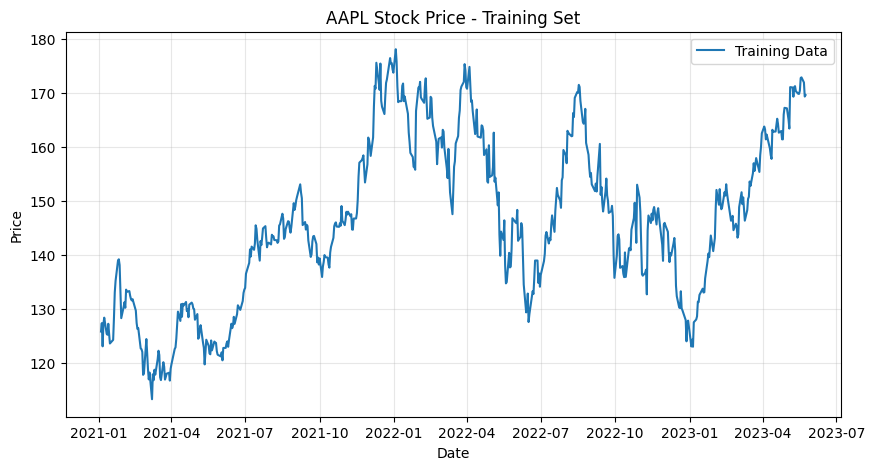

In [13]:
ticker = "AAPL"
data = yf.download(ticker, start="2021-01-01", end="2024-01-01")
prices = data['Close'].dropna()

if isinstance(prices, pd.DataFrame):
    prices = prices.squeeze()

train_size = int(len(prices) * 0.8)
train_data, test_data = prices.iloc[:train_size], prices.iloc[train_size:]

plt.figure(figsize=(10, 5))
plt.plot(train_data, label="Training Data")
plt.title(f"{ticker} Stock Price - Training Set")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

At the first glance it isn't looking like a stationary process.

That's why secondly, we use the ADF test to formally check for stationarity. If the p-value is greater than 0.05, we difference the data incrementally until it becomes stationary to find the optimal order of differencing (d).

Testing original training data:
ADF Statistic: -2.1205
p-value: 0.2363
Testing differenced data (d=1):
ADF Statistic: -18.7090
p-value: 0.0000
Optimal differencing order (d): 1


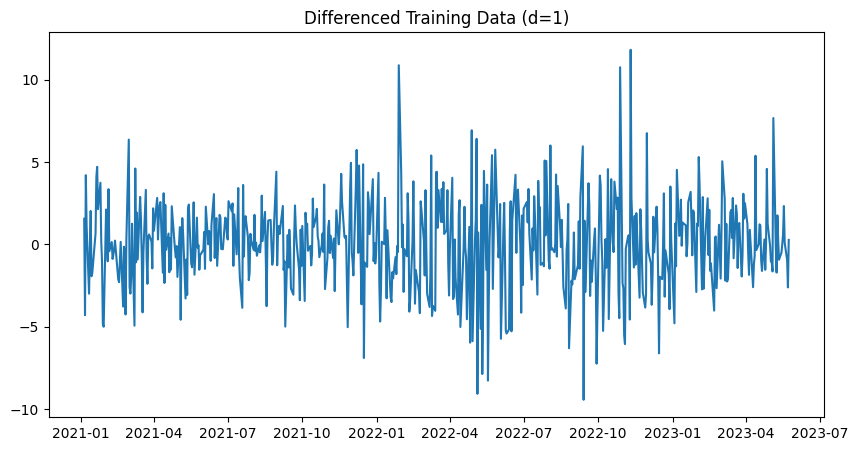

In [14]:
def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    return result[1] <= 0.05

print("Testing original training data:")
is_stationary = check_stationarity(train_data)

d = 0
differenced_data = train_data.copy()

while not is_stationary and d < 3:
    d += 1
    differenced_data = differenced_data.diff().dropna()
    print(f"Testing differenced data (d={d}):")
    is_stationary = check_stationarity(differenced_data)

print(f"Optimal differencing order (d): {d}")

plt.figure(figsize=(10, 5))
plt.plot(differenced_data)
plt.title(f"Differenced Training Data (d={d})")
plt.show()

Now it is looking like a stationary process. We can also check the ACF and PACF plots, which will help visually estimate the potential ranges for the autoregressive (p) and moving average (q) terms.

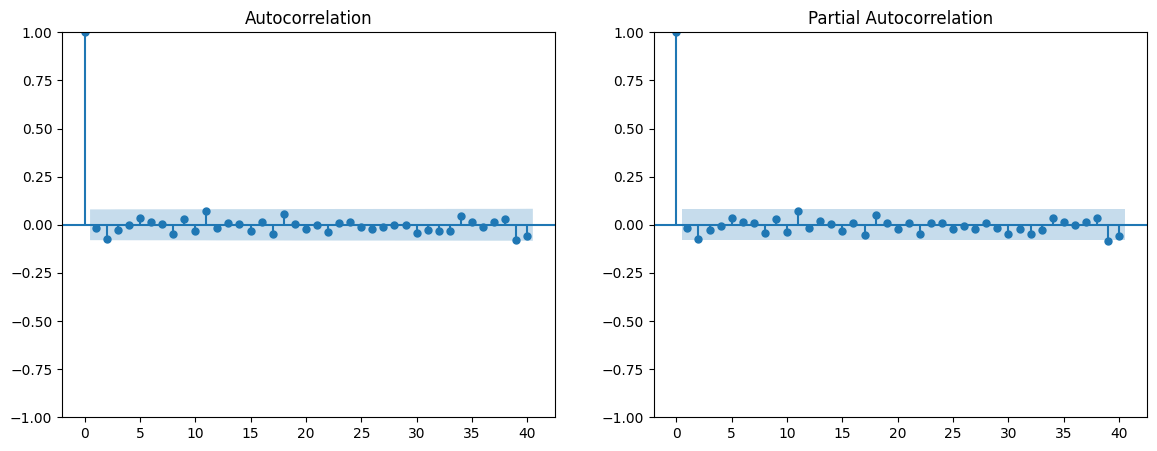

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(differenced_data, ax=axes[0], lags=40)
plot_pacf(differenced_data, ax=axes[1], lags=40)
plt.show()

In [16]:
p_values = range(0, 4)
q_values = range(0, 4)
best_aic = float("inf")
best_order = None

for p, q in itertools.product(p_values, q_values):
    try:
        model = ARIMA(train_data, order=(p, d, q))
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, d, q)
    except:
        continue

print(f"Best ARIMA Order: {best_order} with AIC: {best_aic:.2f}")

Best ARIMA Order: (0, 1, 0) with AIC: 2912.58


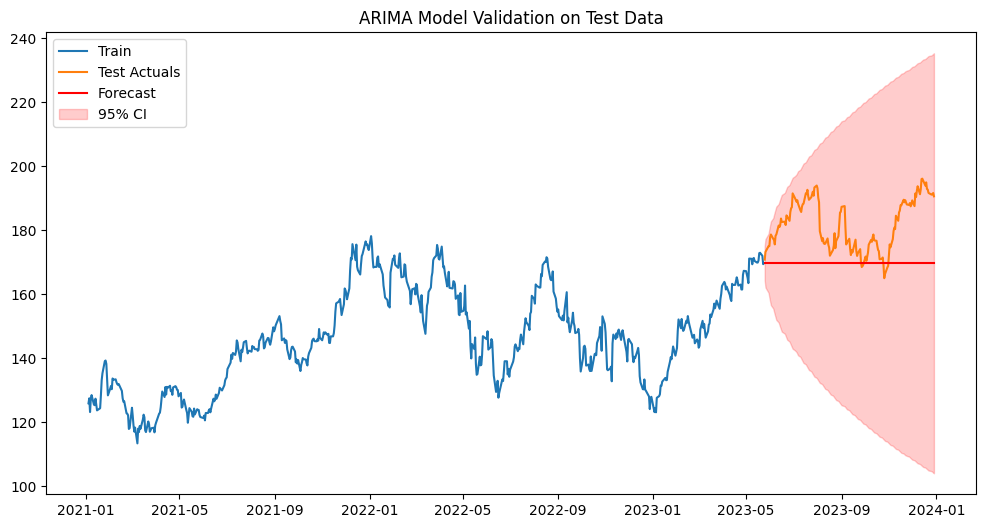

In [17]:
final_model = ARIMA(train_data, order=best_order)
final_results = final_model.fit()

forecast_steps = len(test_data)
forecast_res = final_results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

forecast_mean.index = test_data.index
conf_int.index = test_data.index

plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label="Train")
plt.plot(test_data.index, test_data, label="Test Actuals")
plt.plot(forecast_mean.index, forecast_mean, color="red", label="Forecast")
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="red", alpha=0.2, label="95% CI")
plt.title("ARIMA Model Validation on Test Data")
plt.legend()
plt.show()

## Problem 3.4: GARCH for Volatility

### Objective
Model volatility clustering in financial returns.

### Tasks
- calculate daily returns for S&P 500 index.
- fit GARCH(1,1) model to returns.
- forecast volatility for next 20 days.
- validate using realized volatility.

In [25]:
df_sp500 = pd.read_csv("./../datasets/sp500_yfinance.csv")
df_sp500.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,2058.199951,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
1,2015-01-05,2020.579956,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2,2015-01-06,2002.609985,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
3,2015-01-07,2025.900024,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
4,2015-01-08,2062.139893,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


Before applying the GARCH model, the data must be properly formatted.

The date column is converted to datetime format and the adjusted closing price is selected as the primary price series. The adjusted close is preferred because it accounts for corporate actions such as dividends and stock splits.

In [26]:
df_sp500["Date"] = pd.to_datetime(df_sp500["Date"])

df_sp500 = df_sp500[["Date", "Adj Close"]].copy()
df_sp500 = df_sp500.rename(columns={"Adj Close": "Price"})

df_sp500.head()

,Date,Price
0,2015-01-02,2058.199951
1,2015-01-05,2020.579956
2,2015-01-06,2002.609985
3,2015-01-07,2025.900024
4,2015-01-08,2062.139893


lets visualize

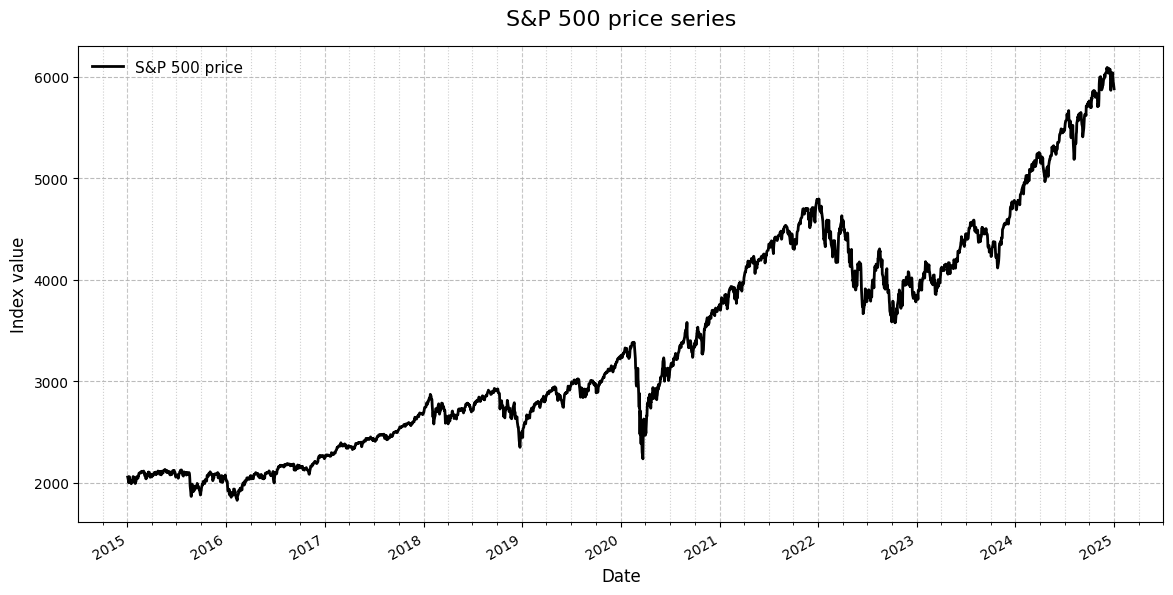

In [27]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_sp500["Date"], df_sp500["Price"], label="S&P 500 price", color="black", linewidth=2)
ax.set_title("S&P 500 price series", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Index value", fontsize=12)

# major ticks every year
# minor ticks every 3 months
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

ax.grid(True, which="major", axis="y", linestyle="--", alpha=0.85)
ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.70)
ax.grid(True, which="minor", axis="x", linestyle=":", alpha=0.60)
ax.legend(frameon=False, fontsize=11)
fig.autofmt_xdate()
plt.show()

GARCH models are applied to returns rather than price levels.

Daily returns are computed as percentage changes between consecutive observations. The values are multiplied by 100, which is a standard convention in volatility modeling and improves numerical stability.

In [28]:
df_sp500["Return"] = df_sp500["Price"].pct_change() * 100
# pct_change() computes relative change between consecutive prices

df_sp500 = df_sp500.dropna().reset_index(drop=True)
df_sp500.head()

,Date,Price,Return
0,2015-01-05,2020.579956,-1.827811
1,2015-01-06,2002.609985,-0.889347
2,2015-01-07,2025.900024,1.162984
3,2015-01-08,2062.139893,1.788828
4,2015-01-09,2044.810059,-0.840381


lets visualize

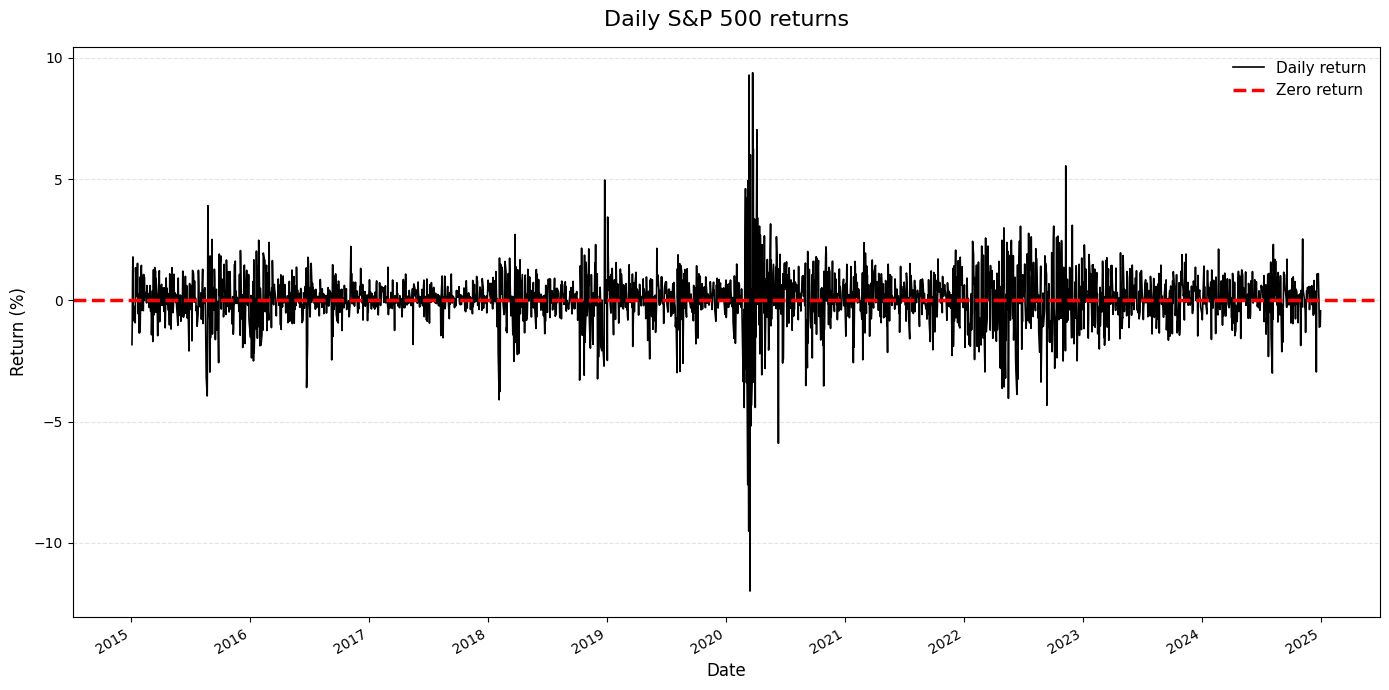

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_sp500["Date"], df_sp500["Return"], color="black", linewidth=1.2, label="Daily return")
ax.axhline(y=0, color="red", linestyle="--", linewidth=2.5, label="Zero return")
ax.set_title("Daily S&P 500 returns", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Return (%)", fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")
ax.legend(frameon=False, fontsize=11)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Financial return series often exhibit volatility clustering. This means that large changes tend to be followed by large changes, and small changes tend to be followed by small changes. To highlight this effect, absolute returns are analyzed.

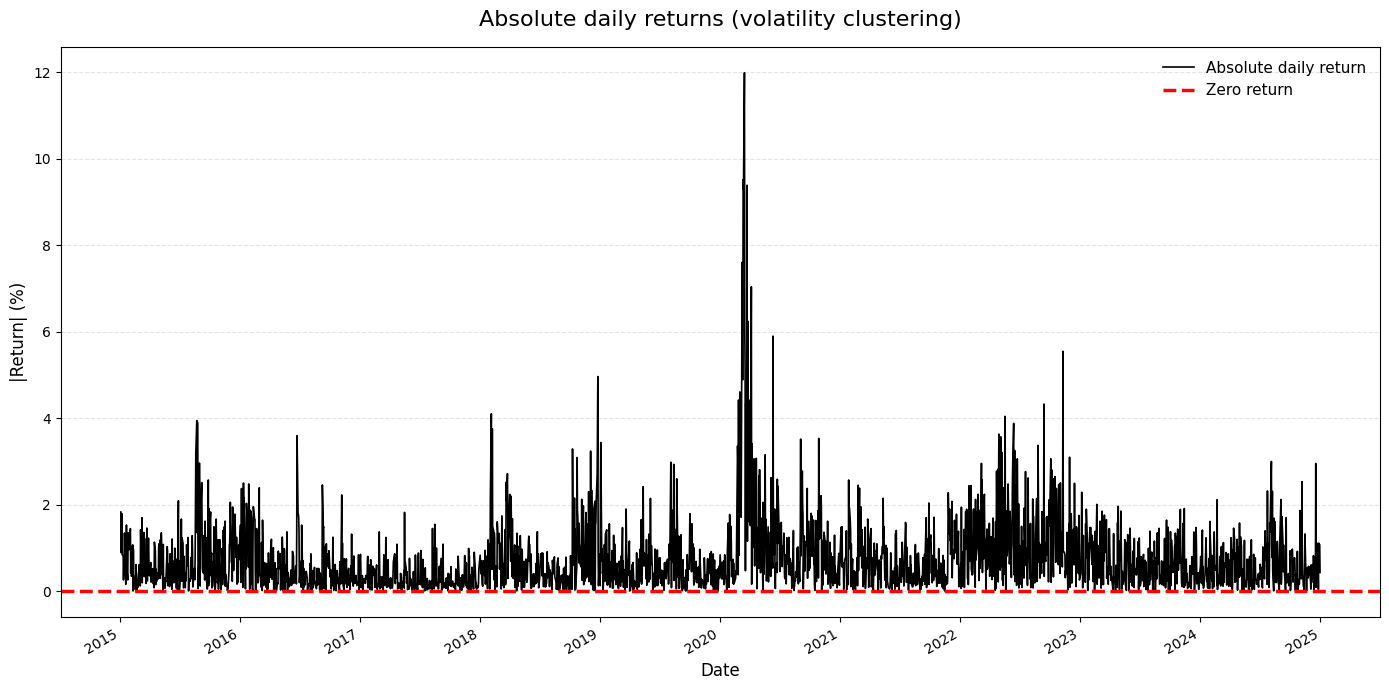

In [30]:
df_sp500["AbsReturn"] = df_sp500["Return"].abs()
# absolute value highlights mggagnitude of returns regardless of direction

fig, ax = plt.subplots(figsize=(14, 7))
plt.plot(df_sp500["Date"], df_sp500["AbsReturn"], color="black", linewidth=1.2, label="Absolute daily return")
ax.axhline(y=0, color="red", linestyle="--", linewidth=2.5, label="Zero return")
ax.set_title("Absolute daily returns (volatility clustering)", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("|Return| (%)", fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")
ax.legend(frameon=False, fontsize=11)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

To evaluate the forecasting performance, the dataset is divided into:
- a training set,
- a test set containing the last 20 observations.

In [31]:
forecast_horizon = 20

train_returns = df_sp500["Return"].iloc[:-forecast_horizon]
test_returns = df_sp500["Return"].iloc[-forecast_horizon:]

train_dates = df_sp500["Date"].iloc[:-forecast_horizon]
test_dates = df_sp500["Date"].iloc[-forecast_horizon:]

Now we fit the GARCH(1,1) model. This is one of the standard models for conditional heteroskedasticity in financial returns. It assumes that current volatility depends on:
- a constant term,
- the squared shock from the previous period,
- the previous conditional variance.

In [32]:
garch_model = arch_model(
    train_returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_result = garch_model.fit(disp="off")
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3195.01
Distribution:                  Normal   AIC:                           6398.02
Method:            Maximum Likelihood   BIC:                           6421.31
                                        No. Observations:                 2495
Date:                Sat, Apr 18 2026   Df Residuals:                     2494
Time:                        19:24:18   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0839  1.476e-02      5.686  1.301e-08 [5.499e-0

The estimated coefficients of the GARCH(1,1) model determine how shocks and past volatility affect current variance. In particular:
- **omega** controls the long-run variance level,
- **alpha[1]** measures the impact of recent shocks,
- **beta[1]** measures persistence of volatility over time.

The fitted GARCH model produces a conditional volatility estimate for each training observation.

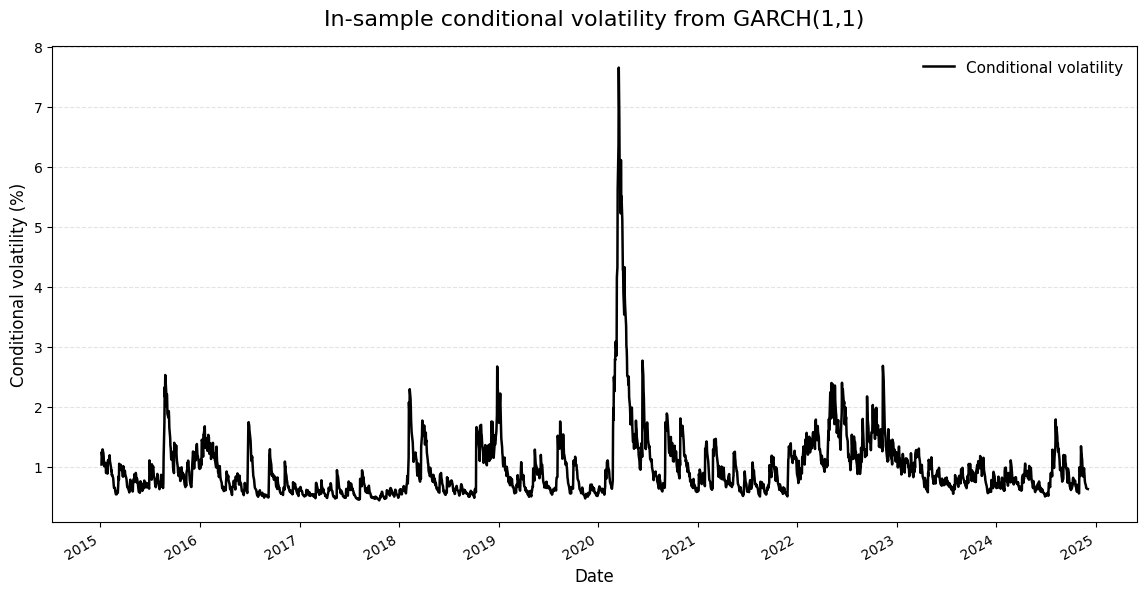

In [38]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(train_dates, garch_result.conditional_volatility, color="black", linewidth=1.8, label="Conditional volatility")
ax.set_title("In-sample conditional volatility from GARCH(1,1)", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Conditional volatility (%)", fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")
ax.legend(frameon=False, fontsize=11)
fig.autofmt_xdate()
plt.show()

The conditional volatility estimated by the GARCH(1,1) model clearly reflects volatility clustering in the data. Periods of elevated volatility appear as sharp spikes, most notably around 2020, followed by gradual decay over time. This behavior indicates that volatility shocks persist, but their impact decreases progressively.

Overall, the model captures the temporal structure of volatility well, distinguishing between calm and turbulent market periods. Now lets forecast 20 days test set.

In [34]:
garch_forecast = garch_result.forecast(horizon=forecast_horizon)
forecast_variance = garch_forecast.variance.iloc[-1].values
# .iloc[-1] selects the final forecast origin
# .values extracts the forecasted variances for all forecast horizons

forecast_volatility = np.sqrt(forecast_variance)
# volatility is the square root of variance

forecast_volatility

array([0.59125625, 0.6136288 , 0.63459074, 0.65429542, 0.67287006,
       0.69042172, 0.7070416 , 0.72280825, 0.73778993, 0.75204648,
       0.7656307 , 0.77858955, 0.79096499, 0.80279474, 0.81411288,
       0.8249503 , 0.83533515, 0.84529316, 0.85484794, 0.86402122])

To validate the forecasts, realized volatility is approximated using the absolute value of observed returns in the test period.

In [35]:
realized_volatility = test_returns.abs().values
# use absolute returns as a simple realized volatility proxy

validation_df = pd.DataFrame({
    "Date": test_dates.values,
    "Forecasted volatility": forecast_volatility,
    "Realized volatility": realized_volatility
})

validation_df.head()

,Date,Forecasted volatility,Realized volatility
0,2024-12-03,0.591256,0.045145
1,2024-12-04,0.613629,0.605142
2,2024-12-05,0.634591,0.186978
3,2024-12-06,0.654295,0.249545
4,2024-12-09,0.672870,0.614421


And finally, plot below compares the 20-day GARCH forecast with realized volatility observed in the test set.

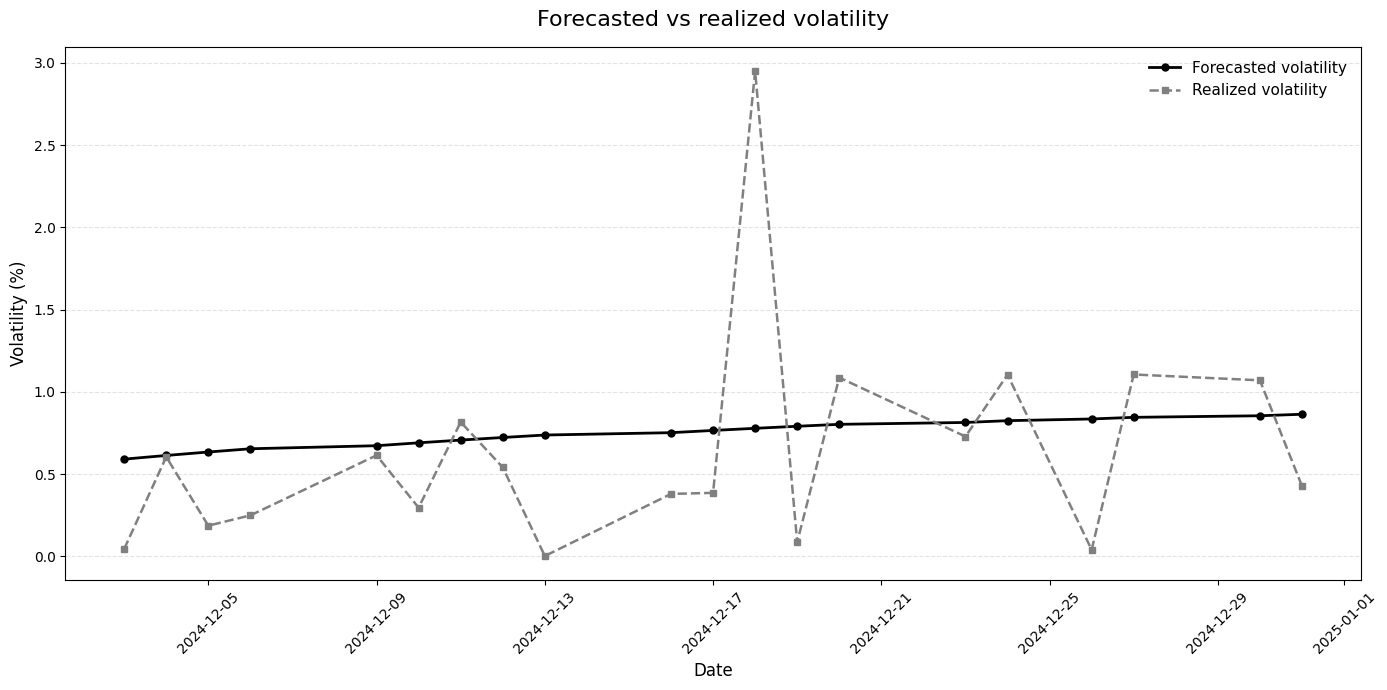

In [36]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(validation_df["Date"],validation_df["Forecasted volatility"],label="Forecasted volatility",color="black",linewidth=2,marker="o",markersize=5)
ax.plot(validation_df["Date"],validation_df["Realized volatility"],label="Realized volatility",color="gray",linewidth=1.8,linestyle="--",marker="s",markersize=4)
ax.set_title("Forecasted vs realized volatility", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Volatility (%)", fontsize=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")
ax.legend(frameon=False, fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The forecasted volatility follows a smooth trajectory, while the realized volatility is highly irregular and exhibits sudden spikes. In particular, large jumps in realized volatility are not captured by the model. This suggests that while the GARCH(1,1) model approximates the general level of volatility, **it is not able to anticipate abrupt market shocks**. The model reacts to volatility changes only after they occur, rather than predicting them in advance.

In addition to visual comparison, a simple error metric can be computed to summarize forecast quality. We will use MAE

In [37]:
mae_volatility = np.mean(np.abs(validation_df["Forecasted volatility"] - validation_df["Realized volatility"]))
print("MAE:", mae_volatility)

MAE: 0.4433396149294356


The Mean Absolute Error (MAE) indicates a noticeable discrepancy between predicted and realized volatility. This error is largely driven by extreme values in the realized volatility, which significantly exceed the smooth forecasts produced by the model. As a result, the model tends to underestimate volatility during periods of sudden market stress.

Therefore, the relatively high MAE reflects both model limitations and the inherently unpredictable nature of financial markets.